# Trabalho Prático – Estrutura de Dados II (DCA3702)

## Análise Estrutural da Malha Viária de Lagoa Nova, Natal/RN

**Disciplina:** DCA3702 – Estrutura de Dados II  
**Região de estudo:** Bairro de Lagoa Nova – Natal, RN  
**Ferramentas:** OSMnx · NetworkX · Gephi

---

### Justificativa da escolha da região

**Lagoa Nova** é um bairro de classe média-alta localizado na Zona Sul de Natal/RN, caracterizado por uma malha viária predominantemente planejada, com traçado em grade nos setores mais antigos e ruas curvilíneas e de cul-de-sac nas expansões residenciais mais recentes. O bairro concentra importantes polos geradores de tráfego: o **Shopping Midway Mall**, o **Parque das Dunas** (maior parque urbano em área de Mata Atlântica do Brasil), instituições de ensino superior e clínicas médicas.

Sua posição estratégica na cidade — servido pelas avenidas **Hermes da Fonseca**, **Salgado Filho** e **Prudente de Morais** — torna Lagoa Nova um nó de passagem obrigatório entre as Zonas Sul, Leste e o centro de Natal. Espera-se que a análise revele **alta concentração de betweenness** nos corredores que conectam essas avenidas, **núcleos k-core** bem definidos na porção interna do bairro e **closeness elevada** nas interseções próximas ao Midway Mall, refletindo a acessibilidade real percebida pelos moradores.

## 0. Instalação e Importações

In [33]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import seaborn as sns
import copy
from collections import Counter

# Configurações de estilo
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = (12, 10)

print(f"OSMnx version:    {ox.__version__}")
print(f"NetworkX version: {nx.__version__}")
print(f"Seaborn version:  {sns.__version__}")

OSMnx version:    2.1.0
NetworkX version: 3.6.1
Seaborn version:  0.13.2


In [34]:
import osmnx as ox

# Busca todas as regiões administrativas de Natal
natal_regions = ox.features_from_place(
    "Natal, Rio Grande do Norte, Brazil",
    tags={"boundary": "administrative"}
)

# Filtra apenas bairros (admin_level 9 ou 10 no Brasil)
bairros = natal_regions[natal_regions['admin_level'].isin(['9', '10'])]

# Lista os nomes disponíveis
nomes = sorted(bairros['name'].dropna().unique().tolist())
for b in nomes:
    print(b)

Alecrim
Amarante
Areia Preta
Barro Vermelho
Bom Pastor
Candelária
Capim Macio
Cidade Alta
Cidade Nova
Cidade da Esperança
Dix-Sept Rosado
Emaús
Encanto Verde
Extremoz
Felipe Camarão
Golandim
Guarapes
Igapó
Jardim Lola
Jardins
Lagoa Nova
Lagoa Seca
Macaíba
Mangabeira
Mãe Luiza
Neópolis
Nordeste
Nossa Senhora da Apresentação
Nossa Senhora de Nazaré
Nova Descoberta
Nova Parnamirim
Novo Amarante
Olho d'Água
Parnamirim
Parque das Colinas
Petrópolis
Pitimbu
Planalto
Ponta Negra
Potengi
Praia do Meio
Quintas
Redinha
Região Sul
Ribeira
Rocas
Salinas
Santos Reis
São Gonçalo do Amarante
Tirol
Uruaçu
Zona Leste
Zona Norte
Zona Oeste


---
## Etapa 1 – Construção do Grafo com OSMnx

Baixamos a rede viária completa do bairro de **Lagoa Nova** em Natal usando `network_type="drive"`, que retorna apenas vias transitáveis por veículos motorizados. O resultado é um **MultiDiGraph** georreferenciado, onde nós representam interseções e arestas representam segmentos de via.

In [35]:
# Baixar a rede viária completa de Natal/RN
place = "Lagoa Nova, Natal, Brazil"

print("Baixando rede viária de Lagoa Nova... (pode levar alguns minutos)")
G = ox.graph_from_place(place, network_type="drive")

print(f"\nTipo do grafo:                  {type(G).__name__}")
print(f"Número de nós (interseções):    {G.number_of_nodes()}")
print(f"Número de arestas (segmentos):  {G.number_of_edges()}")

Baixando rede viária de Lagoa Nova... (pode levar alguns minutos)

Tipo do grafo:                  MultiDiGraph
Número de nós (interseções):    1189
Número de arestas (segmentos):  2712


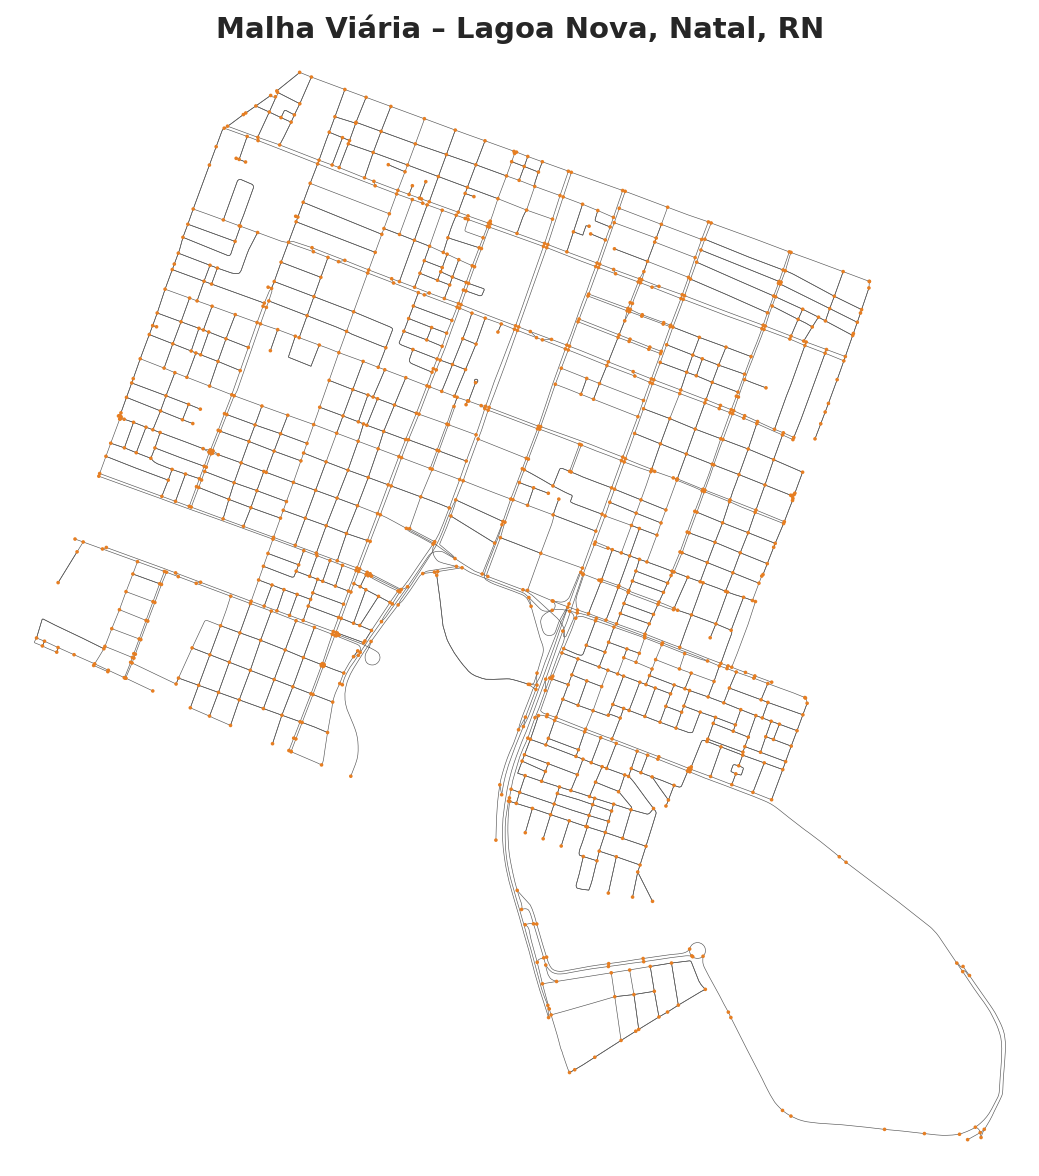

Figura salva: fig01_malha_viaria.png


In [36]:
# Visualização geográfica inicial
fig, ax = ox.plot_graph(
    G,
    node_size=3,
    node_color='#E67E22',
    edge_color='#555555',
    edge_linewidth=0.3,
    bgcolor='white',
    show=False,
    close=False
)
ax.set_title("Malha Viária – Lagoa Nova, Natal, RN", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig01_malha_viaria.png", bbox_inches='tight')
plt.show()
print("Figura salva: fig01_malha_viaria.png")

---
## Etapa 2 – Análise Estrutural com NetworkX

### Preparação dos Grafos

Para as análises de centralidade, convertemos o grafo original em três representações complementares:

| Variável | Tipo | Uso |
|---|---|---|
| `G` | MultiDiGraph (OSMnx) | Grafo original dirigido com geometria |
| `G_undirected` | MultiGraph | Visualizações com `ox.plot_graph` |
| `G_simple` | Graph (NetworkX simples) | Cálculo das métricas de centralidade |
| `G_connected` | Graph (maior componente) | Closeness centrality (requer conectividade) |

In [39]:
# 1. Converter para não direcionado (MultiGraph)

G_undirected = ox.convert.to_undirected(G)

# 2. Converter para grafo simples
G_simple = nx.Graph(G_undirected)

# 3. Grau dos nós
degree_dict = dict(G_undirected.degree())

# 4. Top 10 nós por grau
top_degree = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]


# 5. Remover self-loops
selfloops = list(nx.selfloop_edges(G_simple))
G_simple.remove_edges_from(selfloops)

# 6. Identificar maior componente (LCC) - garante conectividade
largest_cc = max(nx.connected_components(G_simple), key=len)  # Encontra o maior grupo de nós conectados
G_connected = G_simple.subgraph(largest_cc).copy()           # Isola a rede principal sem 'ilhas' viárias

print(f"Nós: {G_simple.number_of_nodes()}, Arestas: {G_simple.number_of_edges()}")

print(f"top_degree:{top_degree}")

Nós: 1189, Arestas: 1857
top_degree:[(503426508, 5), (491803099, 4), (501034099, 4), (501698871, 4), (501699115, 4), (501791672, 4), (501824659, 4), (501824662, 4), (502539381, 4), (502723718, 4)]


In [40]:
# Exemplo de cálculo do core number

core_number = nx.core_number(G_simple)

# Maior valor de core encontrado
max_core = max(core_number.values())
print(f"Maior core number: {max_core}")

# Nós pertencentes ao núcleo mais denso
main_core_nodes = [node for node, core in core_number.items() if core == max_core]
print(f"Número de nós no núcleo principal: {len(main_core_nodes)}")

Maior core number: 2
Número de nós no núcleo principal: 1138


### 2.1 Grau dos Nós e Distribuição de Grau

O **grau** de um nó em uma rede viária corresponde ao número de segmentos de rua conectados a uma interseção. Em Lagoa Nova, espera-se predominância de nós com grau 3 (cruzamentos em T) e grau 4 (cruzamentos em +), típicos de malha planejada. Nós de grau 1 indicam becos ou vias sem saída (*cul-de-sac*), mais frequentes nas ruas internas do bairro.

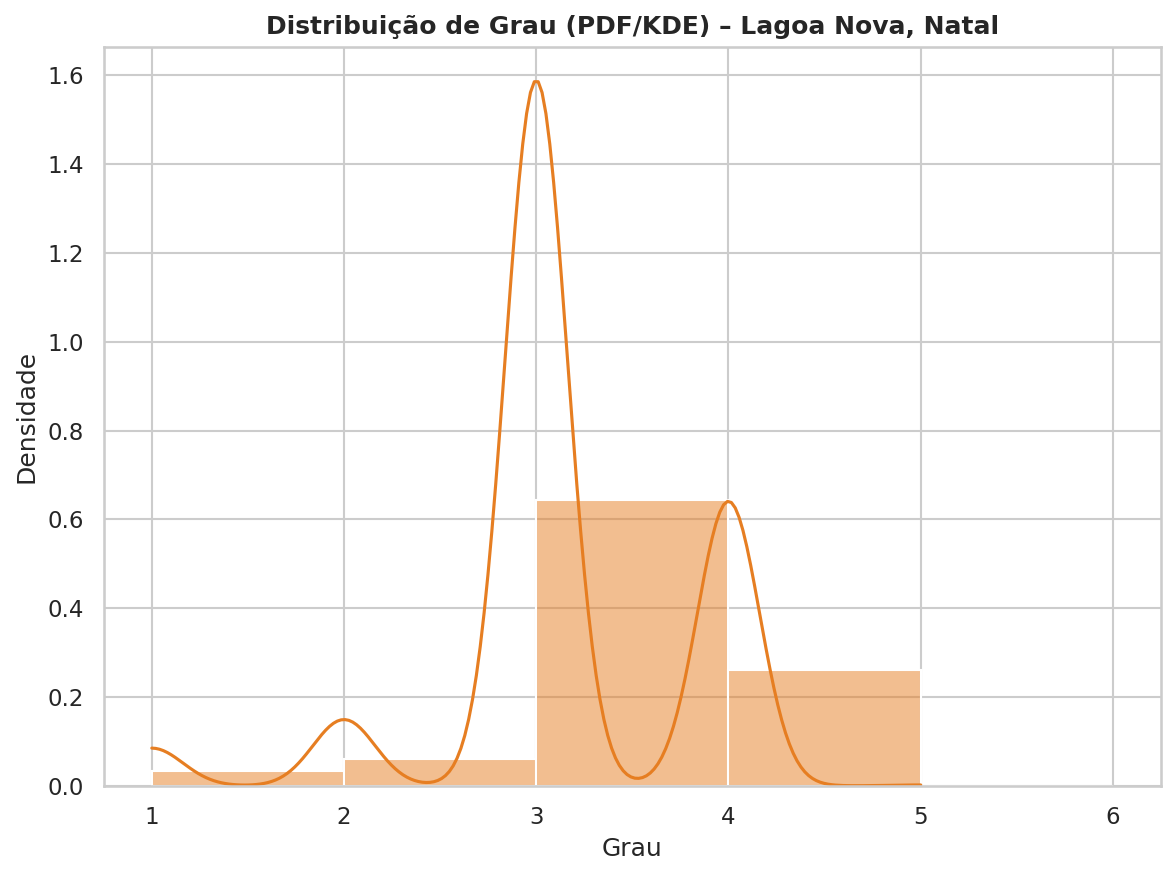

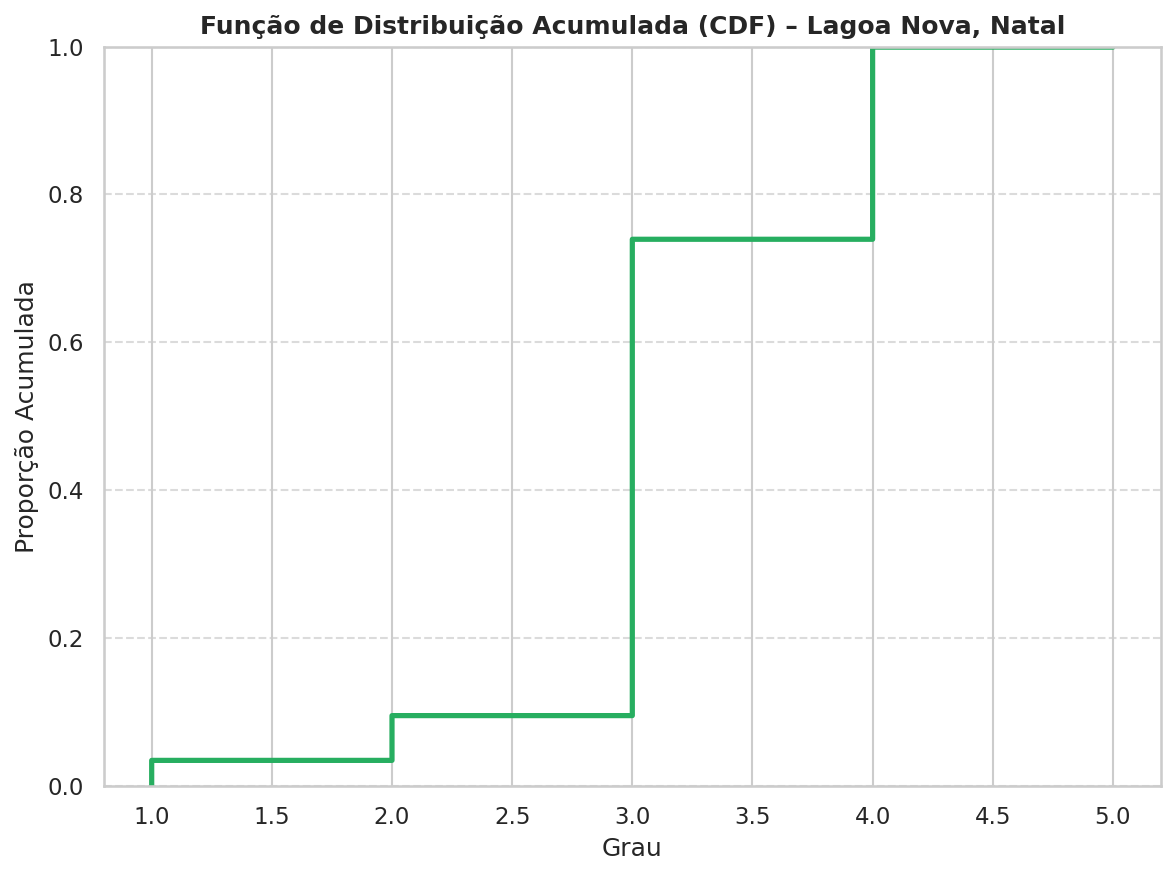

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Preparação dos dados
degree_dict = dict(G_undirected.degree())
degrees = list(degree_dict.values())
nx.set_node_attributes(G_und_multi, degree_dict, 'grau')

# --- FIGURA 1: Histograma (PDF/KDE) ---
plt.figure(figsize=(8, 6))
sns.histplot(degrees, bins=range(min(degrees), max(degrees) + 2), kde=True, color='#E67E22', stat="density")
plt.title('Distribuição de Grau (PDF/KDE) – Lagoa Nova, Natal', fontsize=12, fontweight='bold')
plt.xlabel('Grau')
plt.ylabel('Densidade')
plt.tight_layout()
plt.savefig('fig02a_pdf_grau.png', bbox_inches='tight')
plt.show()

# --- FIGURA 2: Distribuição Acumulada (CDF) ---
plt.figure(figsize=(8, 6))
sns.ecdfplot(degrees, color='#27AE60', linewidth=2.5)
plt.title('Função de Distribuição Acumulada (CDF) – Lagoa Nova, Natal', fontsize=12, fontweight='bold')
plt.xlabel('Grau')
plt.ylabel('Proporção Acumulada')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('fig02b_cdf_grau.png', bbox_inches='tight')
plt.show()

### 2.2 Betweenness Centrality (Eixos Críticos)

A **centralidade de intermediação** (*betweenness*) quantifica com que frequência um nó aparece no menor caminho entre todos os pares de nós da rede. Valores elevados indicam **pontos de gargalo**: remover ou sobrecarregar esses nós impacta desproporcionalmente a fluidez da rede.

Em Lagoa Nova, os maiores valores de betweenness são esperados nas interseções das **avenidas Hermes da Fonseca, Salgado Filho e Prudente de Morais**, que funcionam como corredores de passagem obrigatória entre os bairros vizinhos (Tirol, Petrópolis, Candelária e Nova Descoberta).

Calculando betweenness (k=500)...


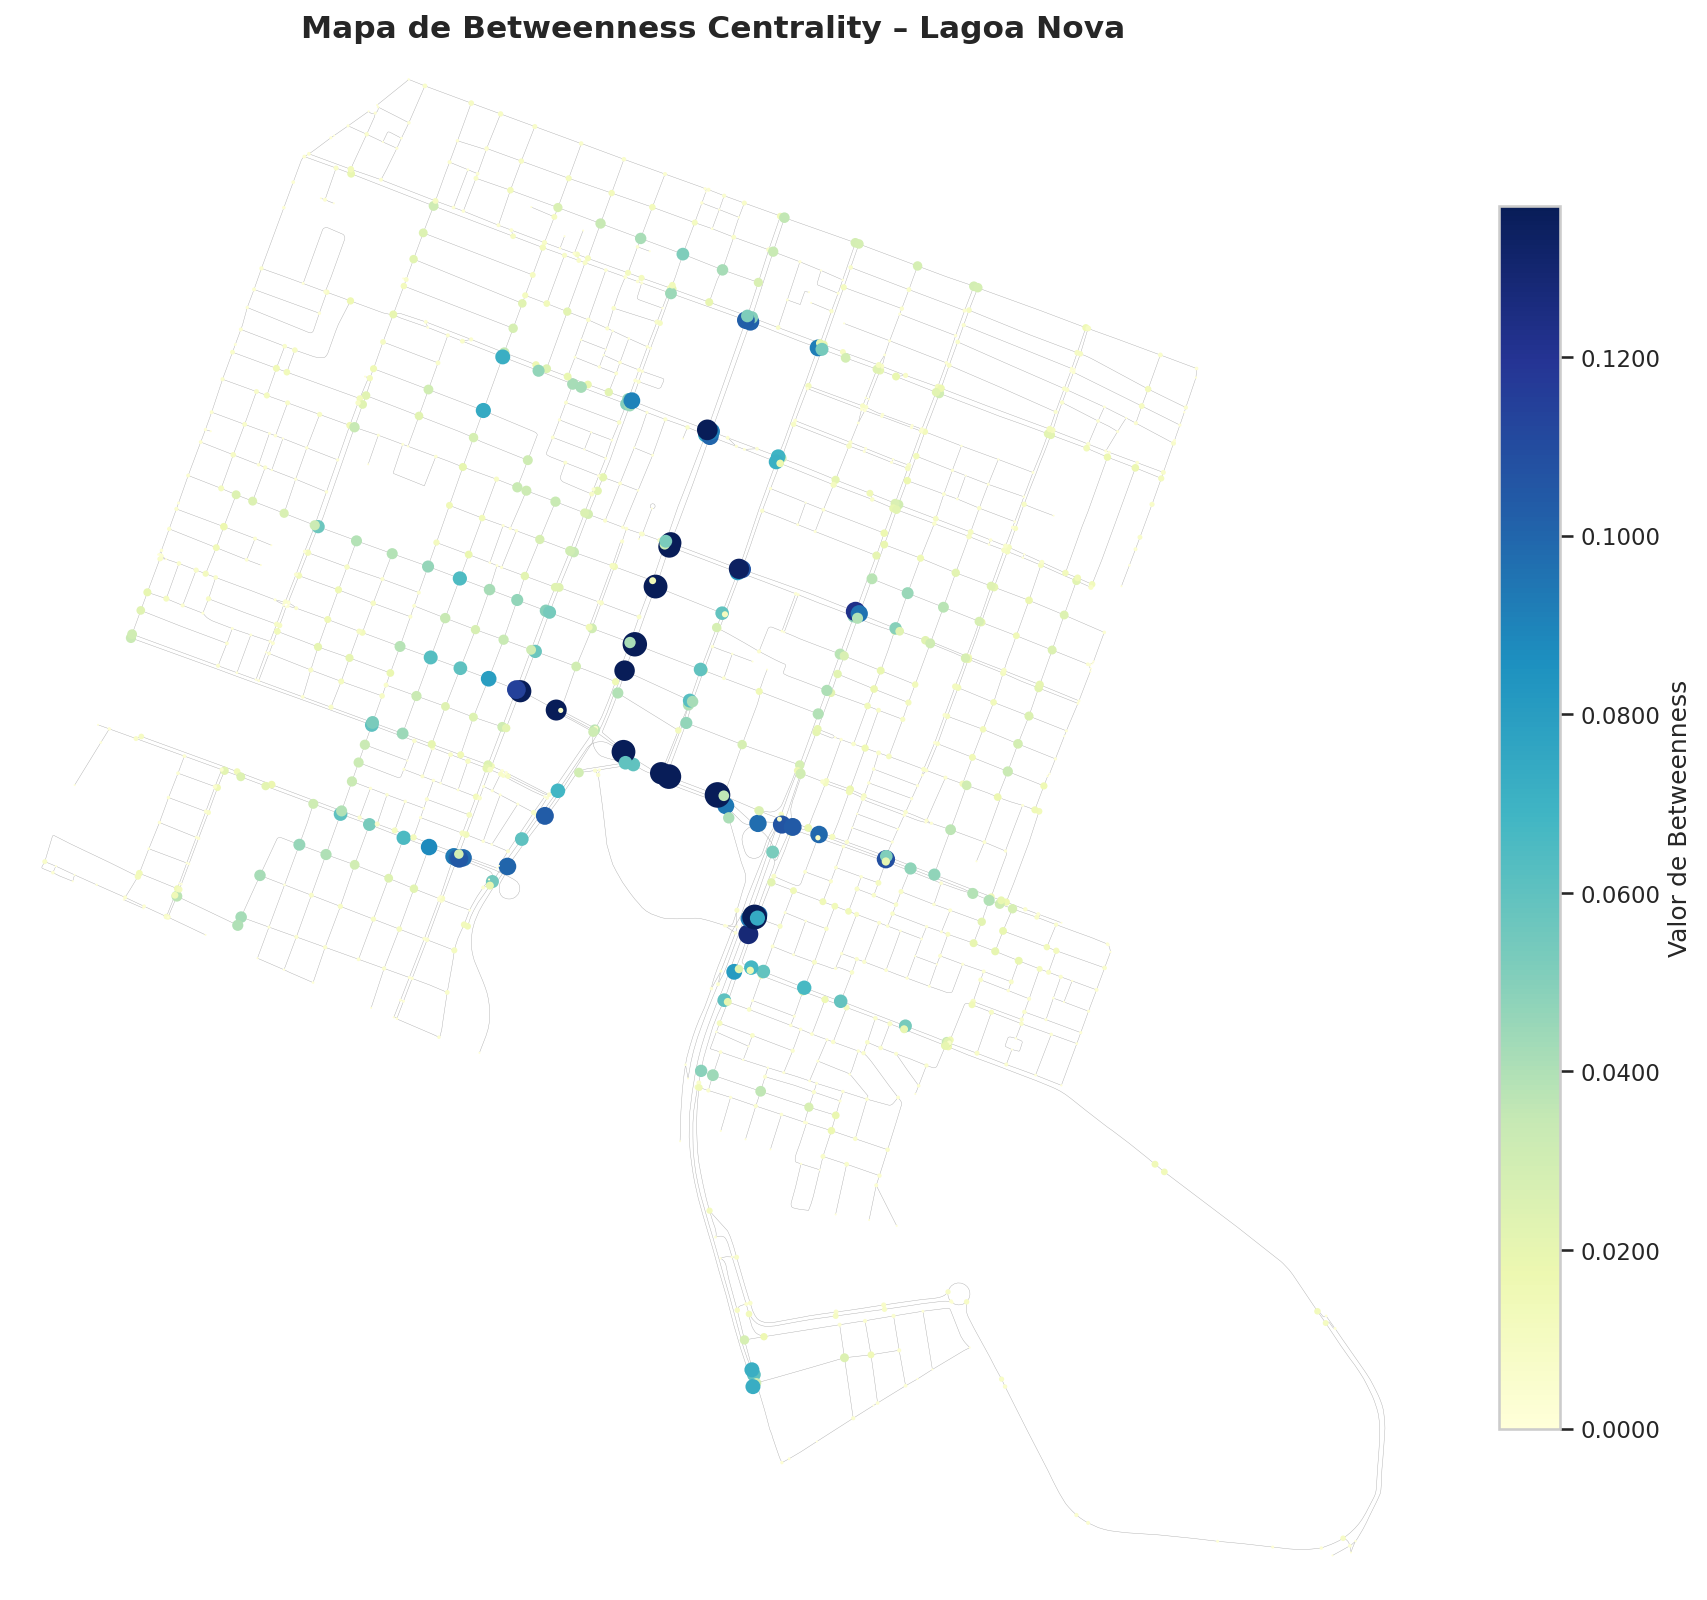

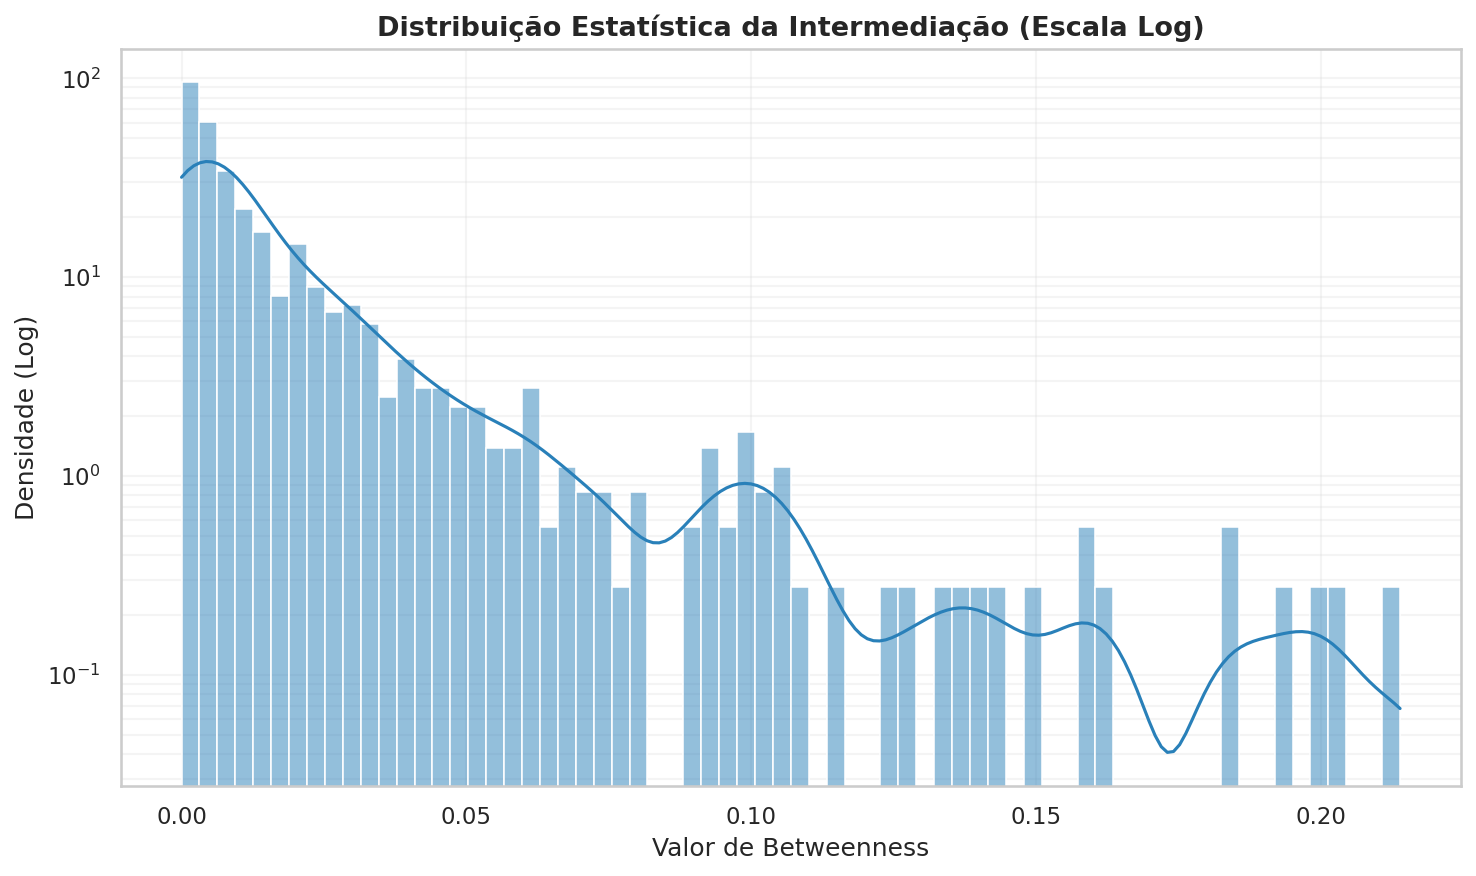

In [45]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import seaborn as sns
import numpy as np
import osmnx as ox

# --- PROCESSAMENTO DOS DADOS ---
print("Calculando betweenness (k=500)...")
betweenness = nx.betweenness_centrality(G_simple, k=500, normalized=True)
nx.set_node_attributes(G_undirected, betweenness, 'betweenness')

betw_vals = np.array([betweenness.get(n, 0) for n in G_undirected.nodes()])
max_b_val = betw_vals.max()

# --- FIGURA 1: MAPA ESPACIAL ---
fig1, ax_map = plt.subplots(figsize=(12, 12))

# Normalização pelo percentil 99 para evitar que outliers "apaguem" o resto da rede
norm_b = mcolors.Normalize(vmin=0, vmax=np.percentile(betw_vals, 99))
cmap_b = cm.YlGnBu

ox.plot_graph(
    G_undirected, 
    node_color=[cmap_b(norm_b(v)) for v in betw_vals],
    node_size=[1 + 150 * v / (max_b_val + 1e-9) for v in betw_vals],
    edge_color='#AAAAAA', 
    edge_linewidth=0.2, 
    bgcolor='white', 
    ax=ax_map, 
    show=False, 
    close=False
)

ax_map.set_title("Mapa de Betweenness Centrality – Lagoa Nova", fontsize=15, fontweight='bold')
sm = cm.ScalarMappable(norm=norm_b, cmap=cmap_b)
plt.colorbar(sm, ax=ax_map, label='Valor de Betweenness', format='%.4f', shrink=0.7)

plt.tight_layout()
plt.savefig('fig04a_betweenness_map.png', bbox_inches='tight')
plt.show()

# --- FIGURA 2: DISTRIBUIÇÃO ESTATÍSTICA ---
plt.figure(figsize=(10, 6))

# Filtramos valores > 0 para que a escala logarítmica faça sentido
sns.histplot(betw_vals[betw_vals > 0], kde=True, color='#2980B9', stat="density")
plt.yscale('log')

plt.title("Distribuição Estatística da Intermediação (Escala Log)", fontsize=13, fontweight='bold')
plt.xlabel("Valor de Betweenness")
plt.ylabel("Densidade (Log)")
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.savefig('fig04b_betweenness_stats.png', bbox_inches='tight')
plt.show()

### 2.3 Closeness Centrality (Acessibilidade Interna)

A **centralidade de proximidade** (*closeness*) mede o inverso da soma das distâncias topológicas de um nó a todos os outros. Nós com closeness alta conseguem alcançar qualquer outro ponto da rede em poucos saltos — em contexto urbano, isso reflete **acessibilidade potencial**.

Para Lagoa Nova, esperam-se valores altos de closeness na região central do bairro, próxima ao **Shopping Midway Mall** e às avenidas estruturantes, e valores mais baixos nas ruas internas de condomínios e nas bordas do bairro, junto ao **Parque das Dunas**.

Calculando closeness (pode demorar)...


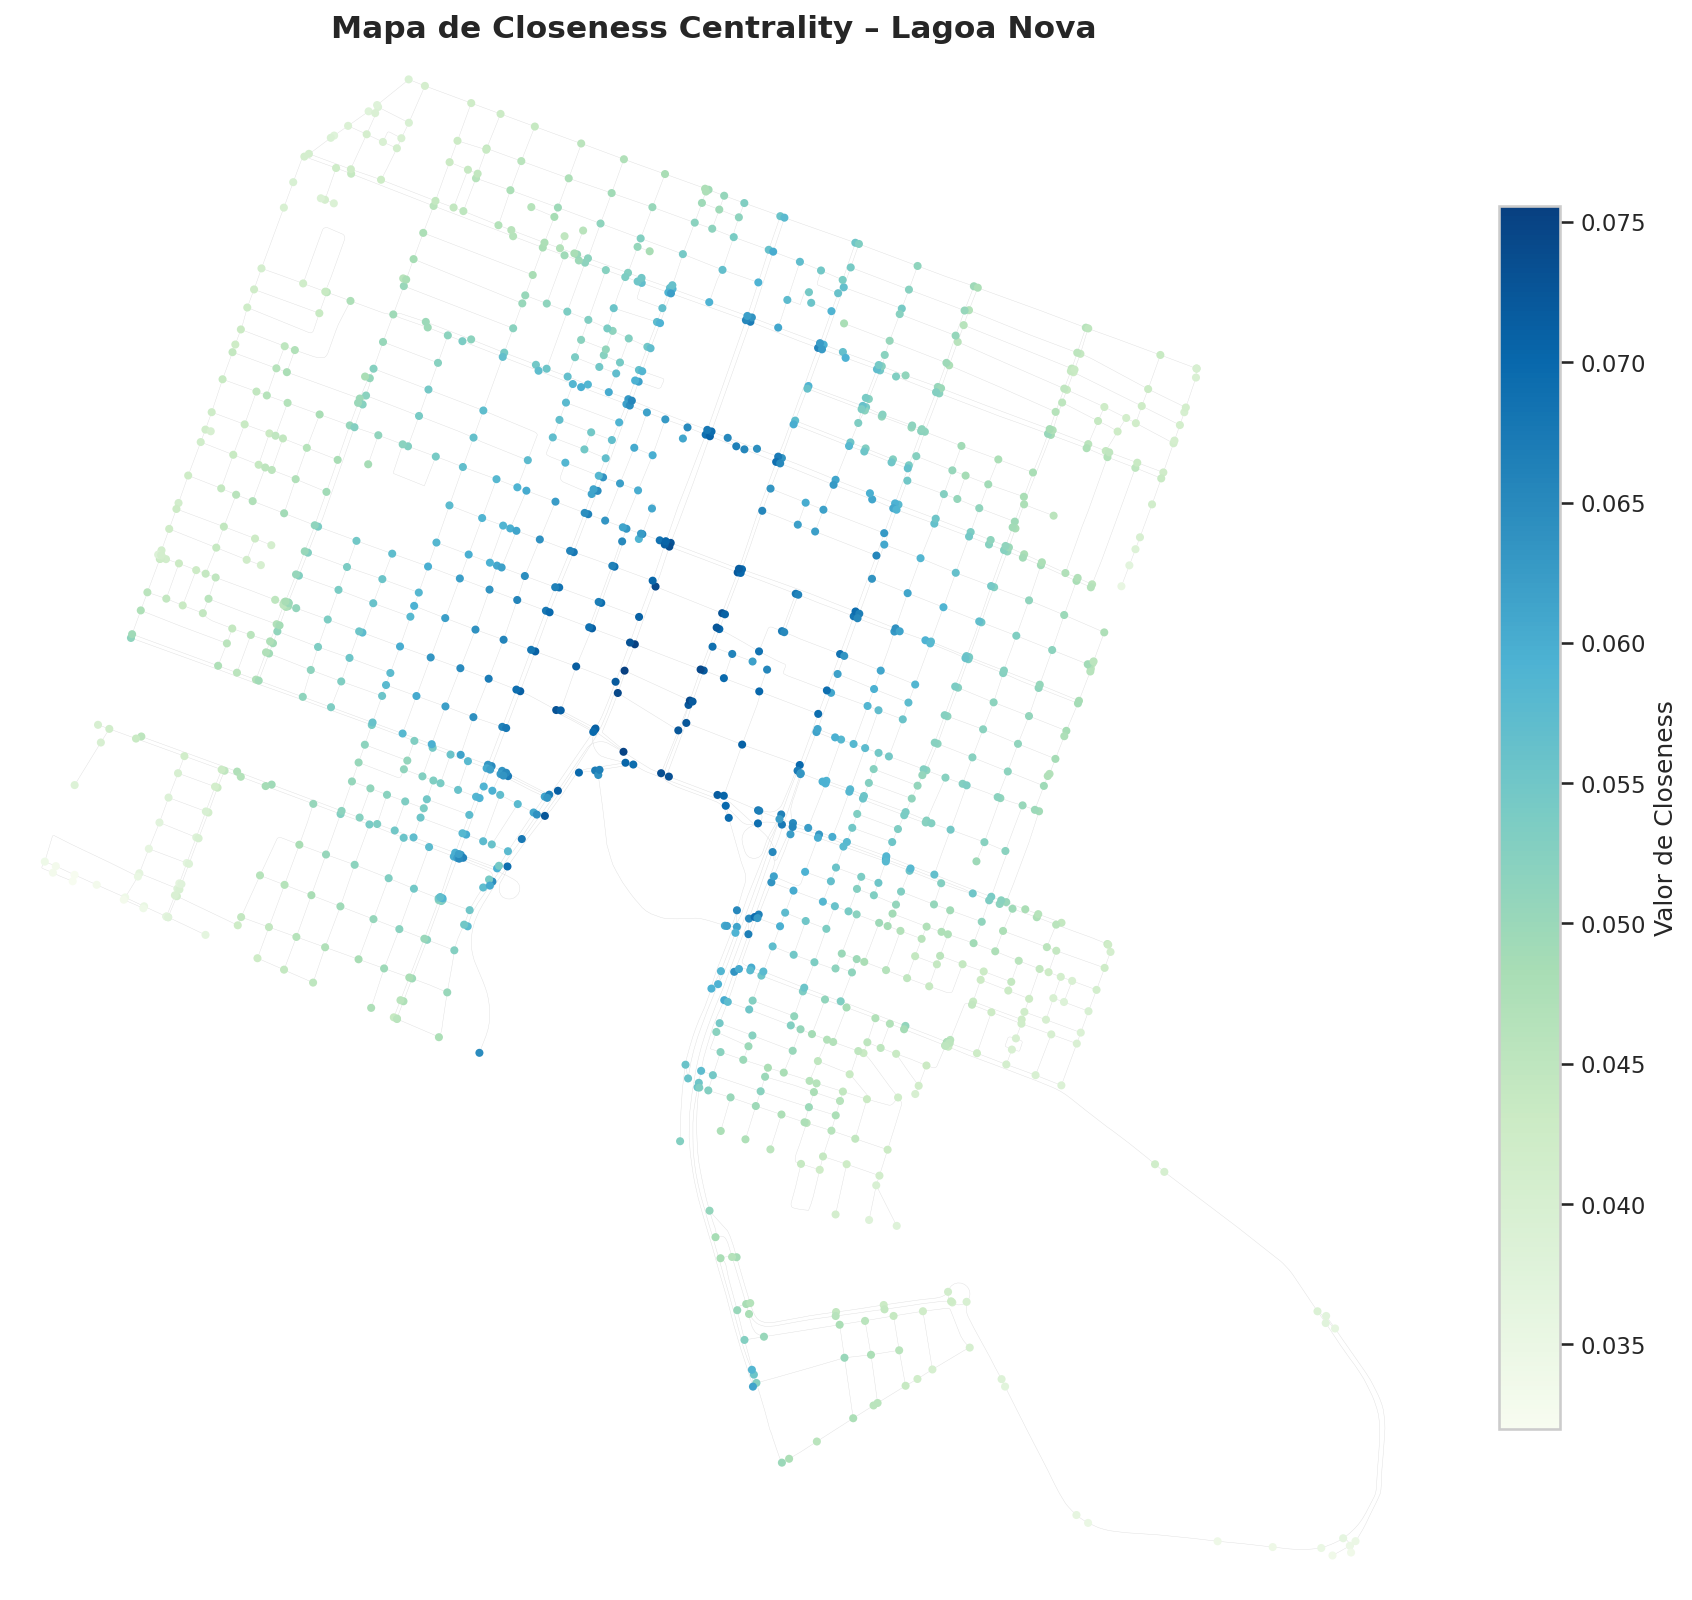

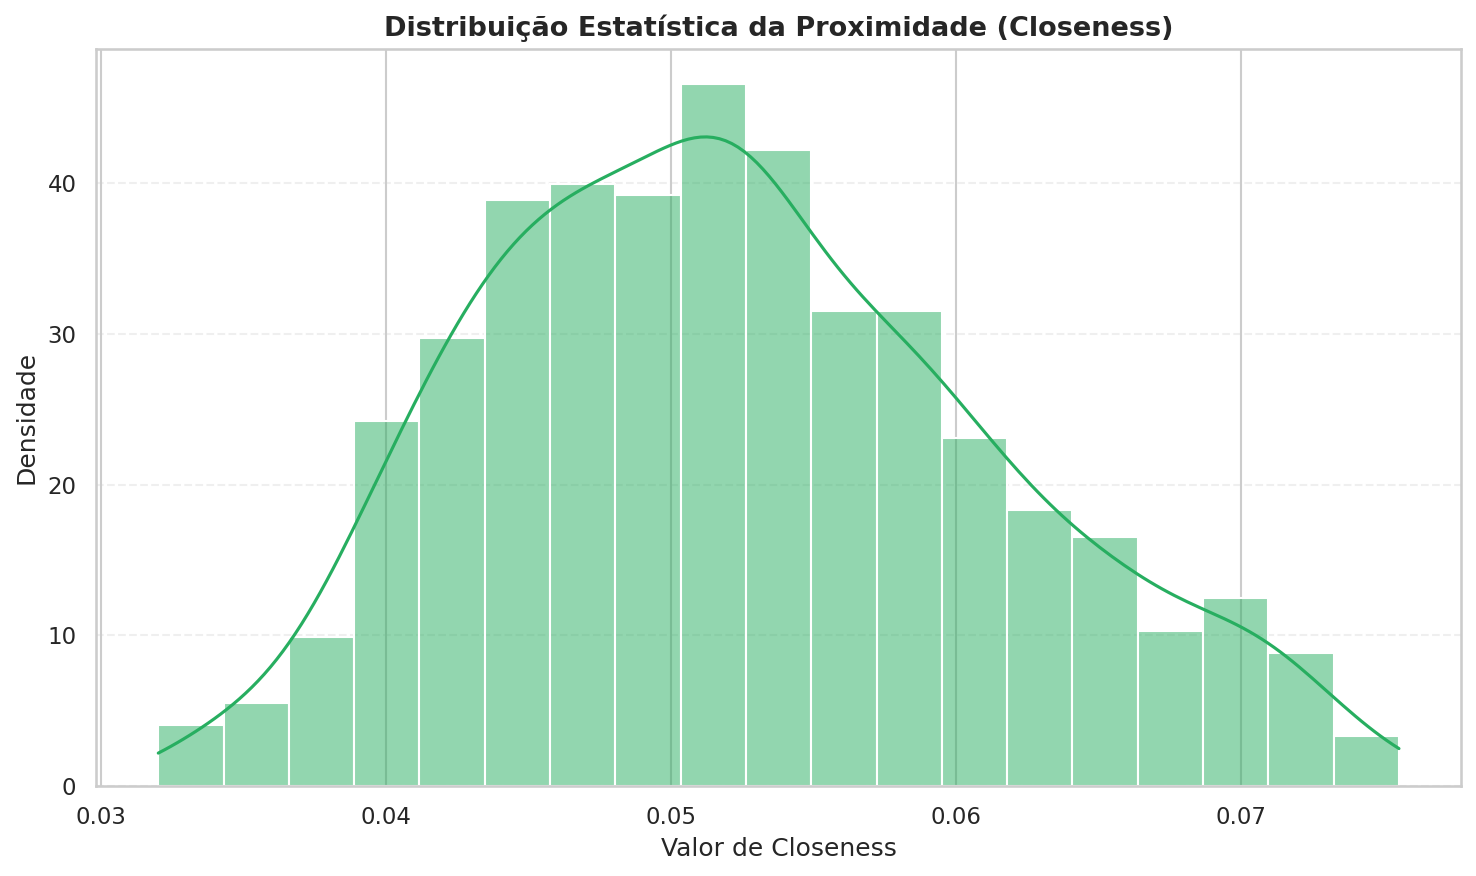

In [48]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import seaborn as sns
import numpy as np
import osmnx as ox

# --- PROCESSAMENTO ---
print("Calculando closeness (pode demorar)...")
closeness = nx.closeness_centrality(G_connected)
nx.set_node_attributes(G_undirected, closeness, 'closeness')

close_vals = np.array([closeness.get(n, 0) for n in G_undirected.nodes()])

# --- FIGURA 1: MAPA ESPACIAL ---
fig1, ax_map = plt.subplots(figsize=(12, 12))

norm_c = mcolors.Normalize(vmin=close_vals.min(), vmax=close_vals.max())
cmap_c = cm.GnBu

ox.plot_graph(
    G_undirected, 
    node_color=[cmap_c(norm_c(v)) for v in close_vals],
    node_size=15, # Aumentado levemente para melhor visibilidade
    edge_color='#DDDDDD', 
    edge_linewidth=0.2, 
    bgcolor='white', 
    ax=ax_map, 
    show=False, 
    close=False
)

ax_map.set_title("Mapa de Closeness Centrality – Lagoa Nova", fontsize=15, fontweight='bold')
sm = cm.ScalarMappable(norm=norm_c, cmap=cmap_c)
plt.colorbar(sm, ax=ax_map, label='Valor de Closeness', format='%.3f', shrink=0.7)

plt.tight_layout()
plt.savefig('fig05a_closeness_map.png', bbox_inches='tight')
plt.show()

# --- FIGURA 2: DISTRIBUIÇÃO ESTATÍSTICA ---
plt.figure(figsize=(10, 6))

sns.histplot(close_vals[close_vals > 0], kde=True, color='#27AE60', stat="density")

plt.title("Distribuição Estatística da Proximidade (Closeness)", fontsize=13, fontweight='bold')
plt.xlabel("Valor de Closeness")
plt.ylabel("Densidade")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('fig05b_closeness_stats.png', bbox_inches='tight')
plt.show()

### 2.4 K-Core vs K-Shell Analysis

A **decomposição k-core** descreve a estrutura hierárquica de coesão da rede. Cada nó recebe um *shell index* igual ao maior valor de *k* para o qual ele pertence a um subgrafo onde todo nó tem grau ≥ k.

- **K-Shell (índice de shell):** revela todas as camadas concêntricas da rede, da periferia (k=1) ao núcleo mais denso.
- **Max K-Core:** o subgrafo mais coeso — em redes viárias, representa o "miolo" da malha onde a redundância de rotas é máxima.

Em Lagoa Nova, o max k-core deve coincidir com a área servida pelas principais avenidas, enquanto os shells externos correspondem às ruas locais de acesso único.

In [49]:
core_number = nx.core_number(G_simple)
max_k = max(core_number.values())
nx.set_node_attributes(G_und_multi, core_number, 'shell_index')
print(f"Máximo índice de Shell (k-max): {max_k}")

Máximo índice de Shell (k-max): 2


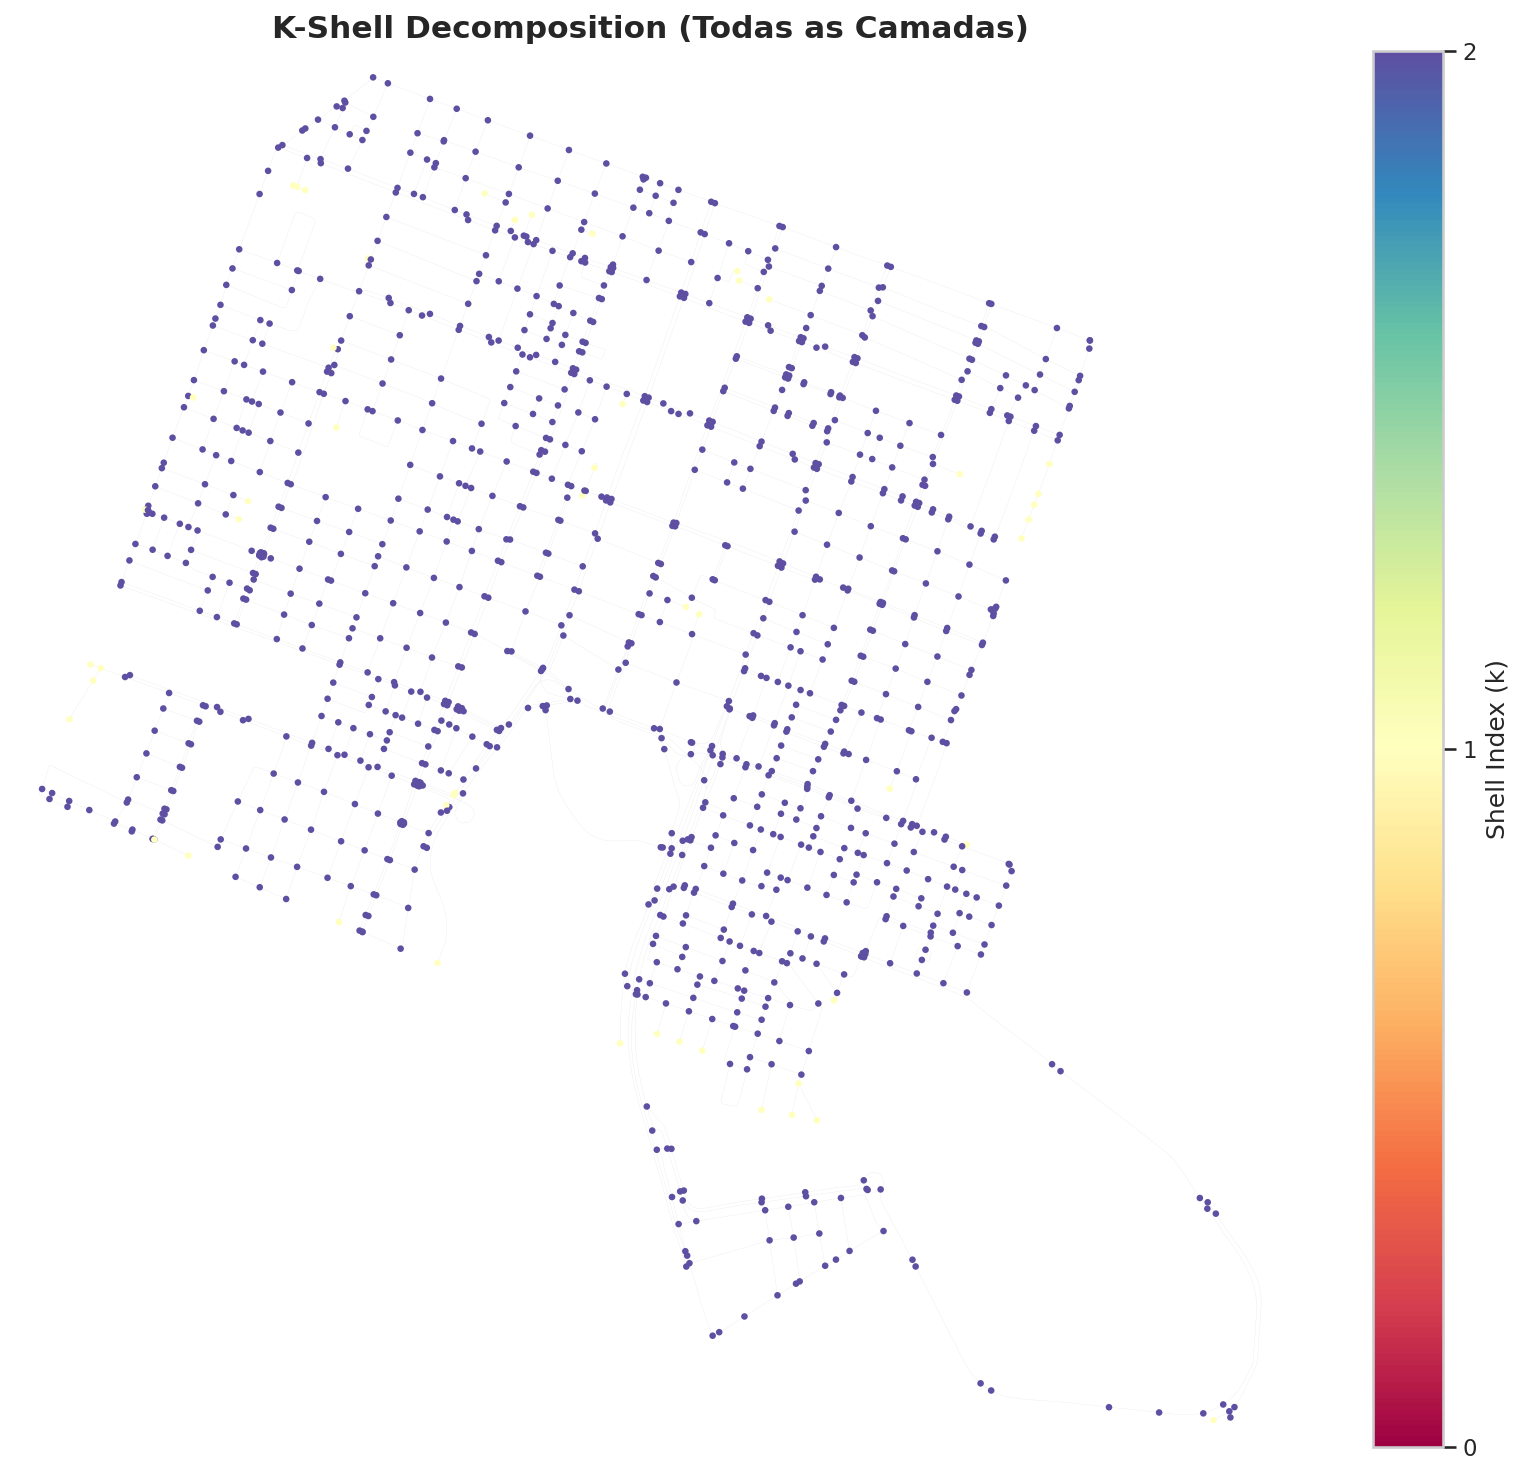

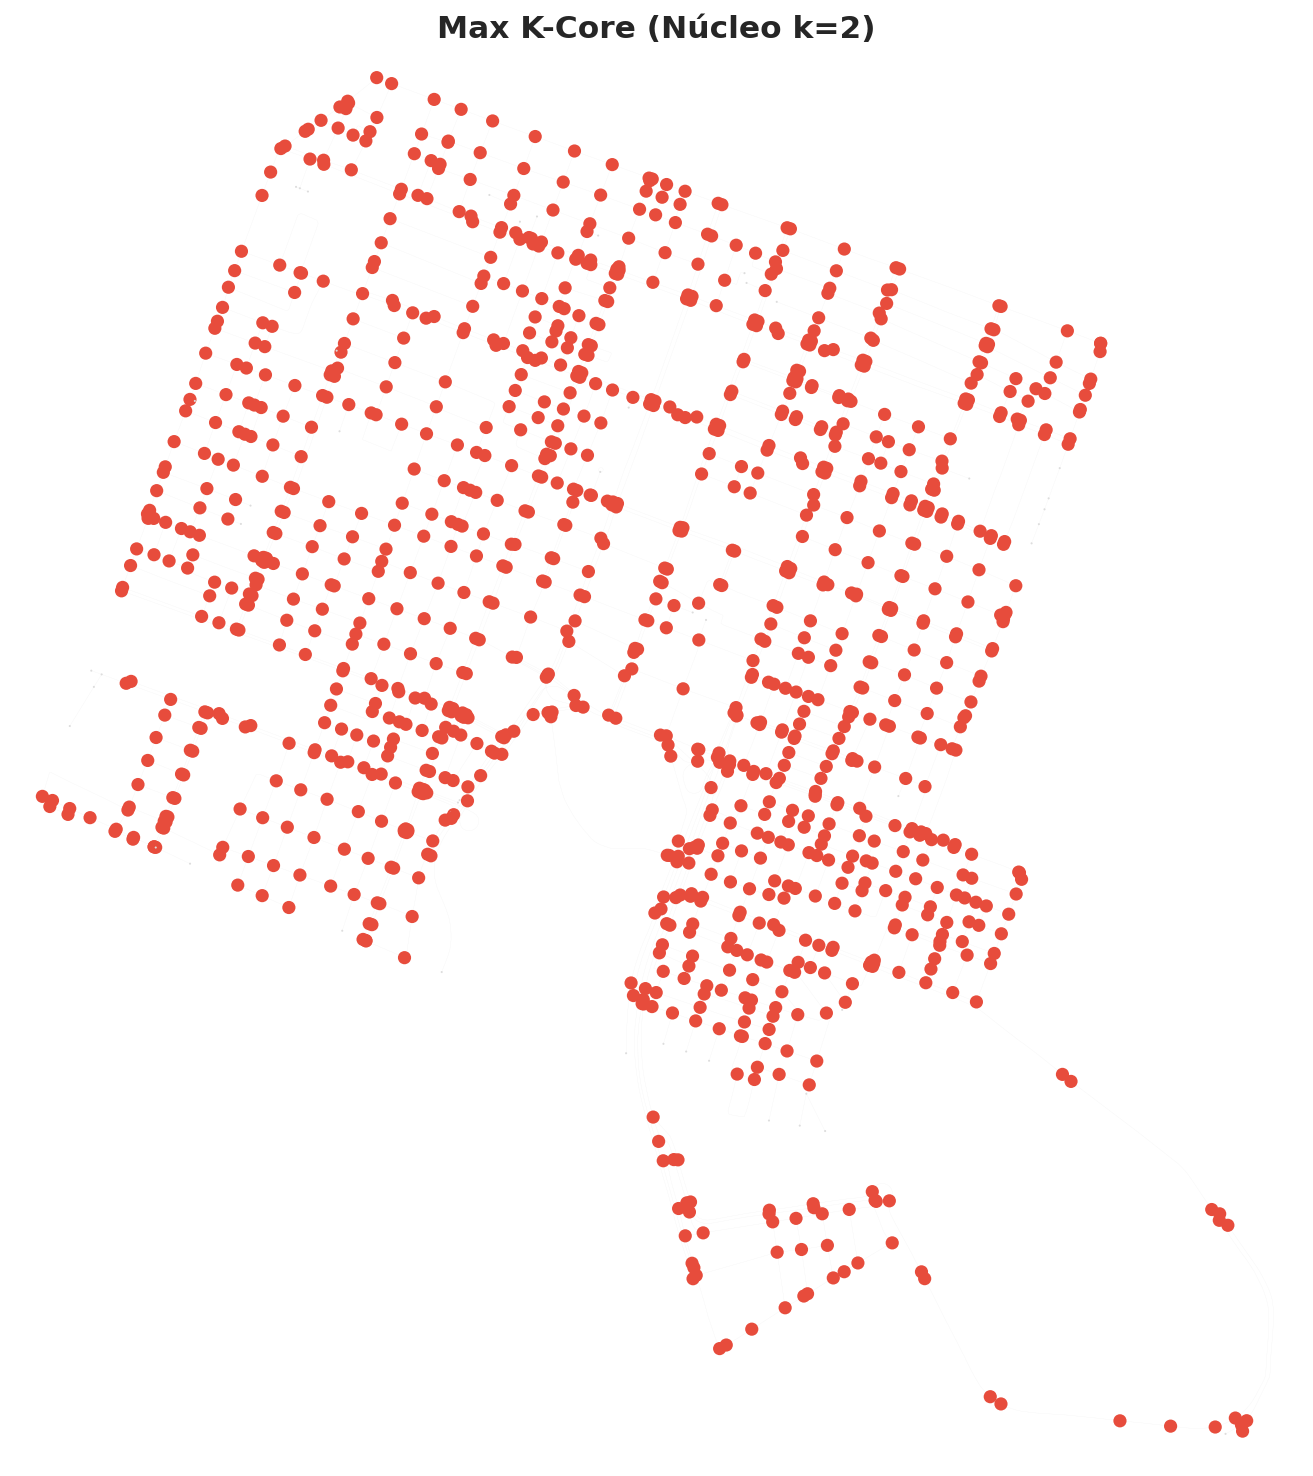

In [50]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import osmnx as ox

# --- FIGURA 1: K-SHELL (Todas as camadas) ---
fig1, ax1 = plt.subplots(figsize=(12, 10))

norm_shell = mcolors.Normalize(vmin=0, vmax=max_k)
cmap_shell = cm.Spectral
node_colors_shell = [cmap_shell(norm_shell(core_number.get(n, 0))) for n in G_und_multi.nodes()]

ox.plot_graph(
    G_undirected, 
    node_color=node_colors_shell,
    node_size=10, 
    edge_color='#DDDDDD', 
    edge_linewidth=0.1, 
    bgcolor='white', 
    ax=ax1, 
    show=False, 
    close=False
)

ax1.set_title(f"K-Shell Decomposition (Todas as Camadas)", fontsize=15, fontweight='bold')
sm1 = cm.ScalarMappable(norm=norm_shell, cmap=cmap_shell)
plt.colorbar(sm1, ax=ax1, label='Shell Index (k)', ticks=range(max_k + 1))

plt.tight_layout()
plt.savefig('fig06a_kshell.png', bbox_inches='tight')
plt.show()

# --- FIGURA 2: K-CORE (Destaque do Núcleo Principal) ---
fig2, ax2 = plt.subplots(figsize=(12, 10))

max_core_nodes = set(n for n, k in core_number.items() if k == max_k)
node_colors_core = ['#E74C3C' if n in max_core_nodes else '#DDDDDD' for n in G_und_multi.nodes()]
node_sizes_core = [40 if n in max_core_nodes else 1 for n in G_und_multi.nodes()]

ox.plot_graph(
    G_undirected, 
    node_color=node_colors_core, 
    node_size=node_sizes_core,
    edge_color='#EEEEEE', 
    edge_linewidth=0.1, 
    bgcolor='white', 
    ax=ax2, 
    show=False, 
    close=False
)

ax2.set_title(f"Max K-Core (Núcleo k={max_k})", fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('fig06b_kcore.png', bbox_inches='tight')
plt.show()

### 2.5 Eigenvector Centrality (Influência por Vizinhança)

A **centralidade de autovetor** (*eigenvector*) mede a influência de um nó levando em conta não apenas quantas conexões ele possui, mas **a importância dos seus vizinhos**. Um nó com poucos vizinhos, mas altamente conectados, pode ter eigenvector alto — ao contrário do grau, que trata todas as conexões como iguais.

Em Lagoa Nova, esperam-se valores altos de eigenvector nos nós próximos às avenidas estruturantes, onde os vizinhos imediatos também são nós de alta conectividade. Ruas internas de baixo grau, mesmo que próximas geograficamente dessas avenidas, tendem a ter eigenvector baixo por estarem isoladas topologicamente.

Calculando eigenvector centrality...


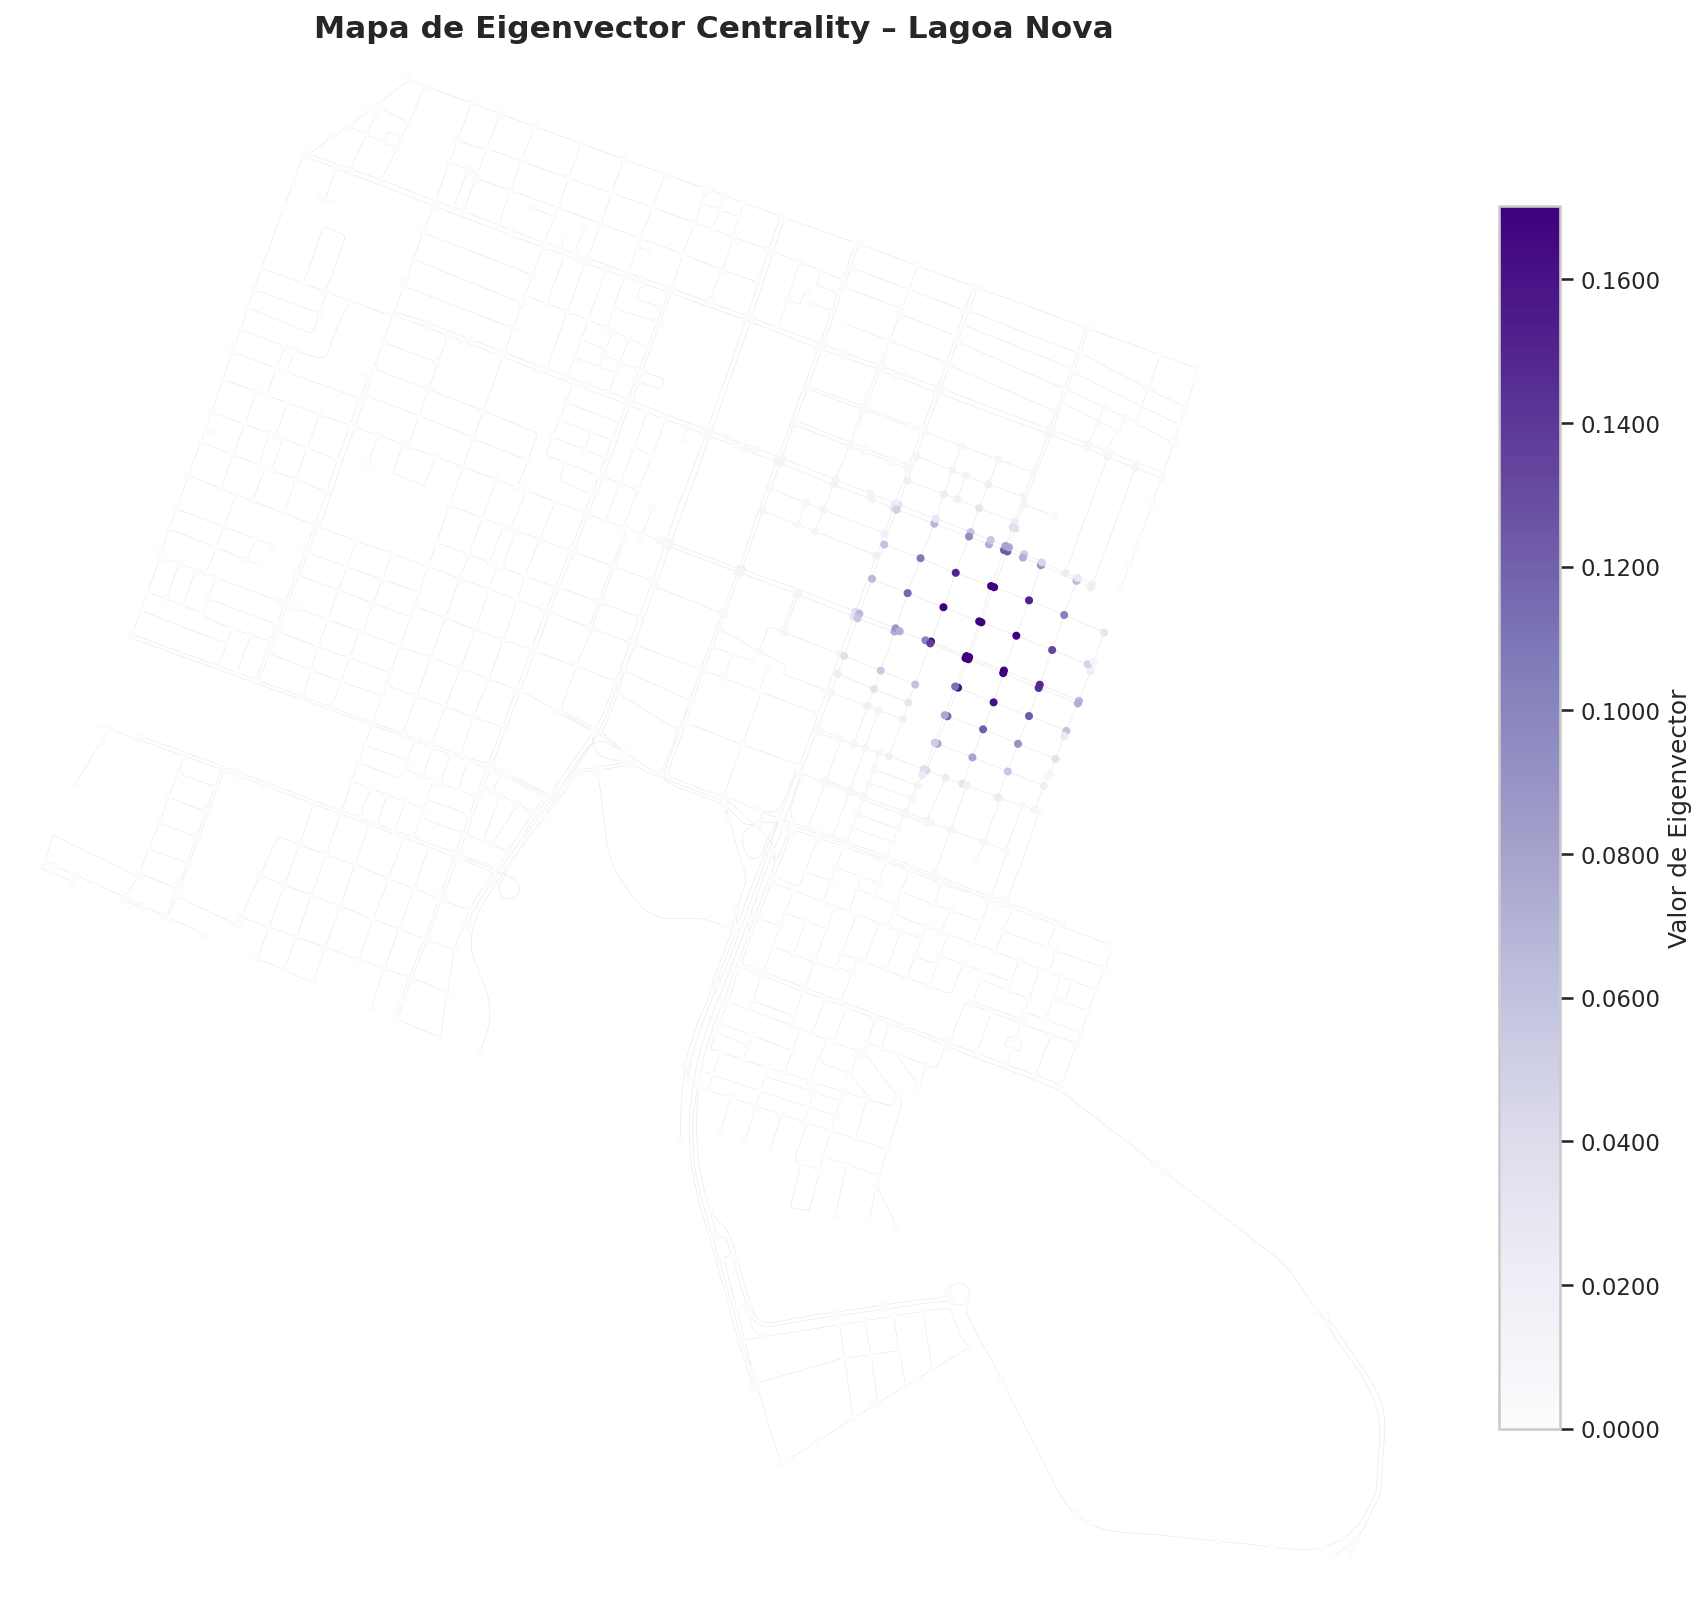

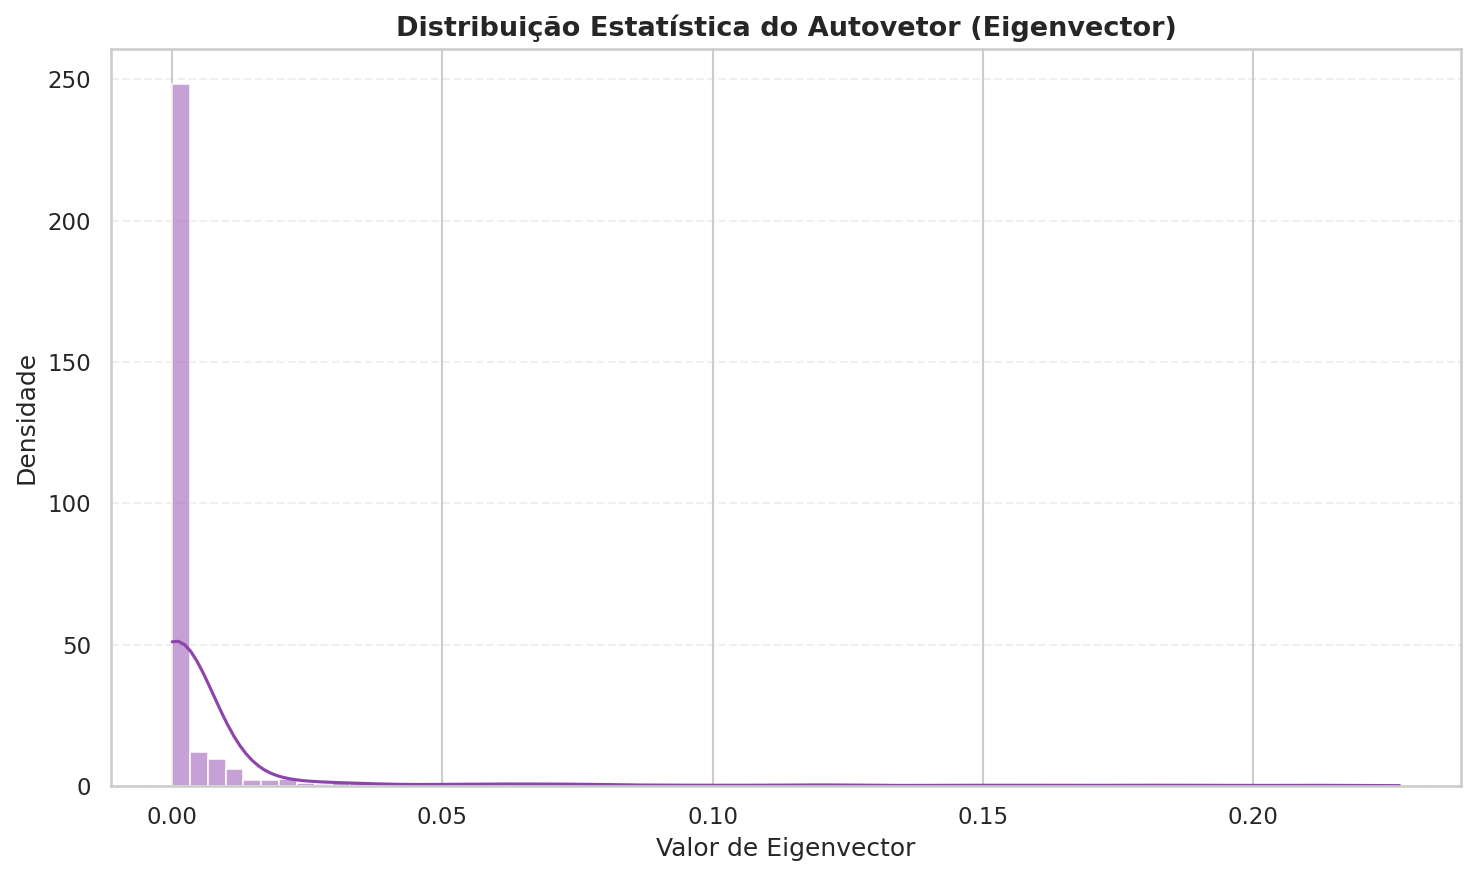

In [52]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import seaborn as sns
import numpy as np
import osmnx as ox

# --- PROCESSAMENTO ---
print("Calculando eigenvector centrality...")
try:
    eigenvector = nx.eigenvector_centrality(G_simple, max_iter=1000)
except nx.PowerIterationFailedConvergence:
    eigenvector = nx.eigenvector_centrality_numpy(G_simple)

nx.set_node_attributes(G_und_multi, eigenvector, 'eigenvector')
eig_vals = np.array([eigenvector.get(n, 0) for n in G_und_multi.nodes()])

# --- FIGURA 1: MAPA ESPACIAL ---
fig1, ax_map = plt.subplots(figsize=(12, 12))

# Normalização pelo percentil 99 para evitar que um único nó dominante apague o restante
norm_e = mcolors.Normalize(vmin=eig_vals.min(), vmax=np.percentile(eig_vals, 99))
cmap_e = cm.Purples

ox.plot_graph(
    G_und_multi,
    node_color=[cmap_e(norm_e(v)) for v in eig_vals],
    node_size=15, 
    edge_color='#DDDDDD', 
    edge_linewidth=0.2, 
    bgcolor='white',
    ax=ax_map, 
    show=False, 
    close=False
)

ax_map.set_title("Mapa de Eigenvector Centrality – Lagoa Nova", fontsize=15, fontweight='bold')
sm = cm.ScalarMappable(norm=norm_e, cmap=cmap_e)
plt.colorbar(sm, ax=ax_map, label='Valor de Eigenvector', format='%.4f', shrink=0.7)

plt.tight_layout()
plt.savefig('fig07a_eigenvector_map.png', bbox_inches='tight')
plt.show()

# --- FIGURA 2: DISTRIBUIÇÃO ESTATÍSTICA ---
plt.figure(figsize=(10, 6))

# Filtro de valores positivos para melhor visualização da curva
sns.histplot(eig_vals[eig_vals > 0], kde=True, color='#8E44AD', stat="density")

plt.title("Distribuição Estatística do Autovetor (Eigenvector)", fontsize=13, fontweight='bold')
plt.xlabel("Valor de Eigenvector")
plt.ylabel("Densidade")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('fig07b_eigenvector_stats.png', bbox_inches='tight')
plt.show()

---
## Etapa 3 – Análise Comparativa das Métricas

O **PairGrid** a seguir cruza as cinco métricas calculadas para cada nó da rede de Lagoa Nova: grau, betweenness, closeness, eigenvector e shell index. O objetivo é identificar correlações e dissociações que revelem a estrutura funcional do bairro.

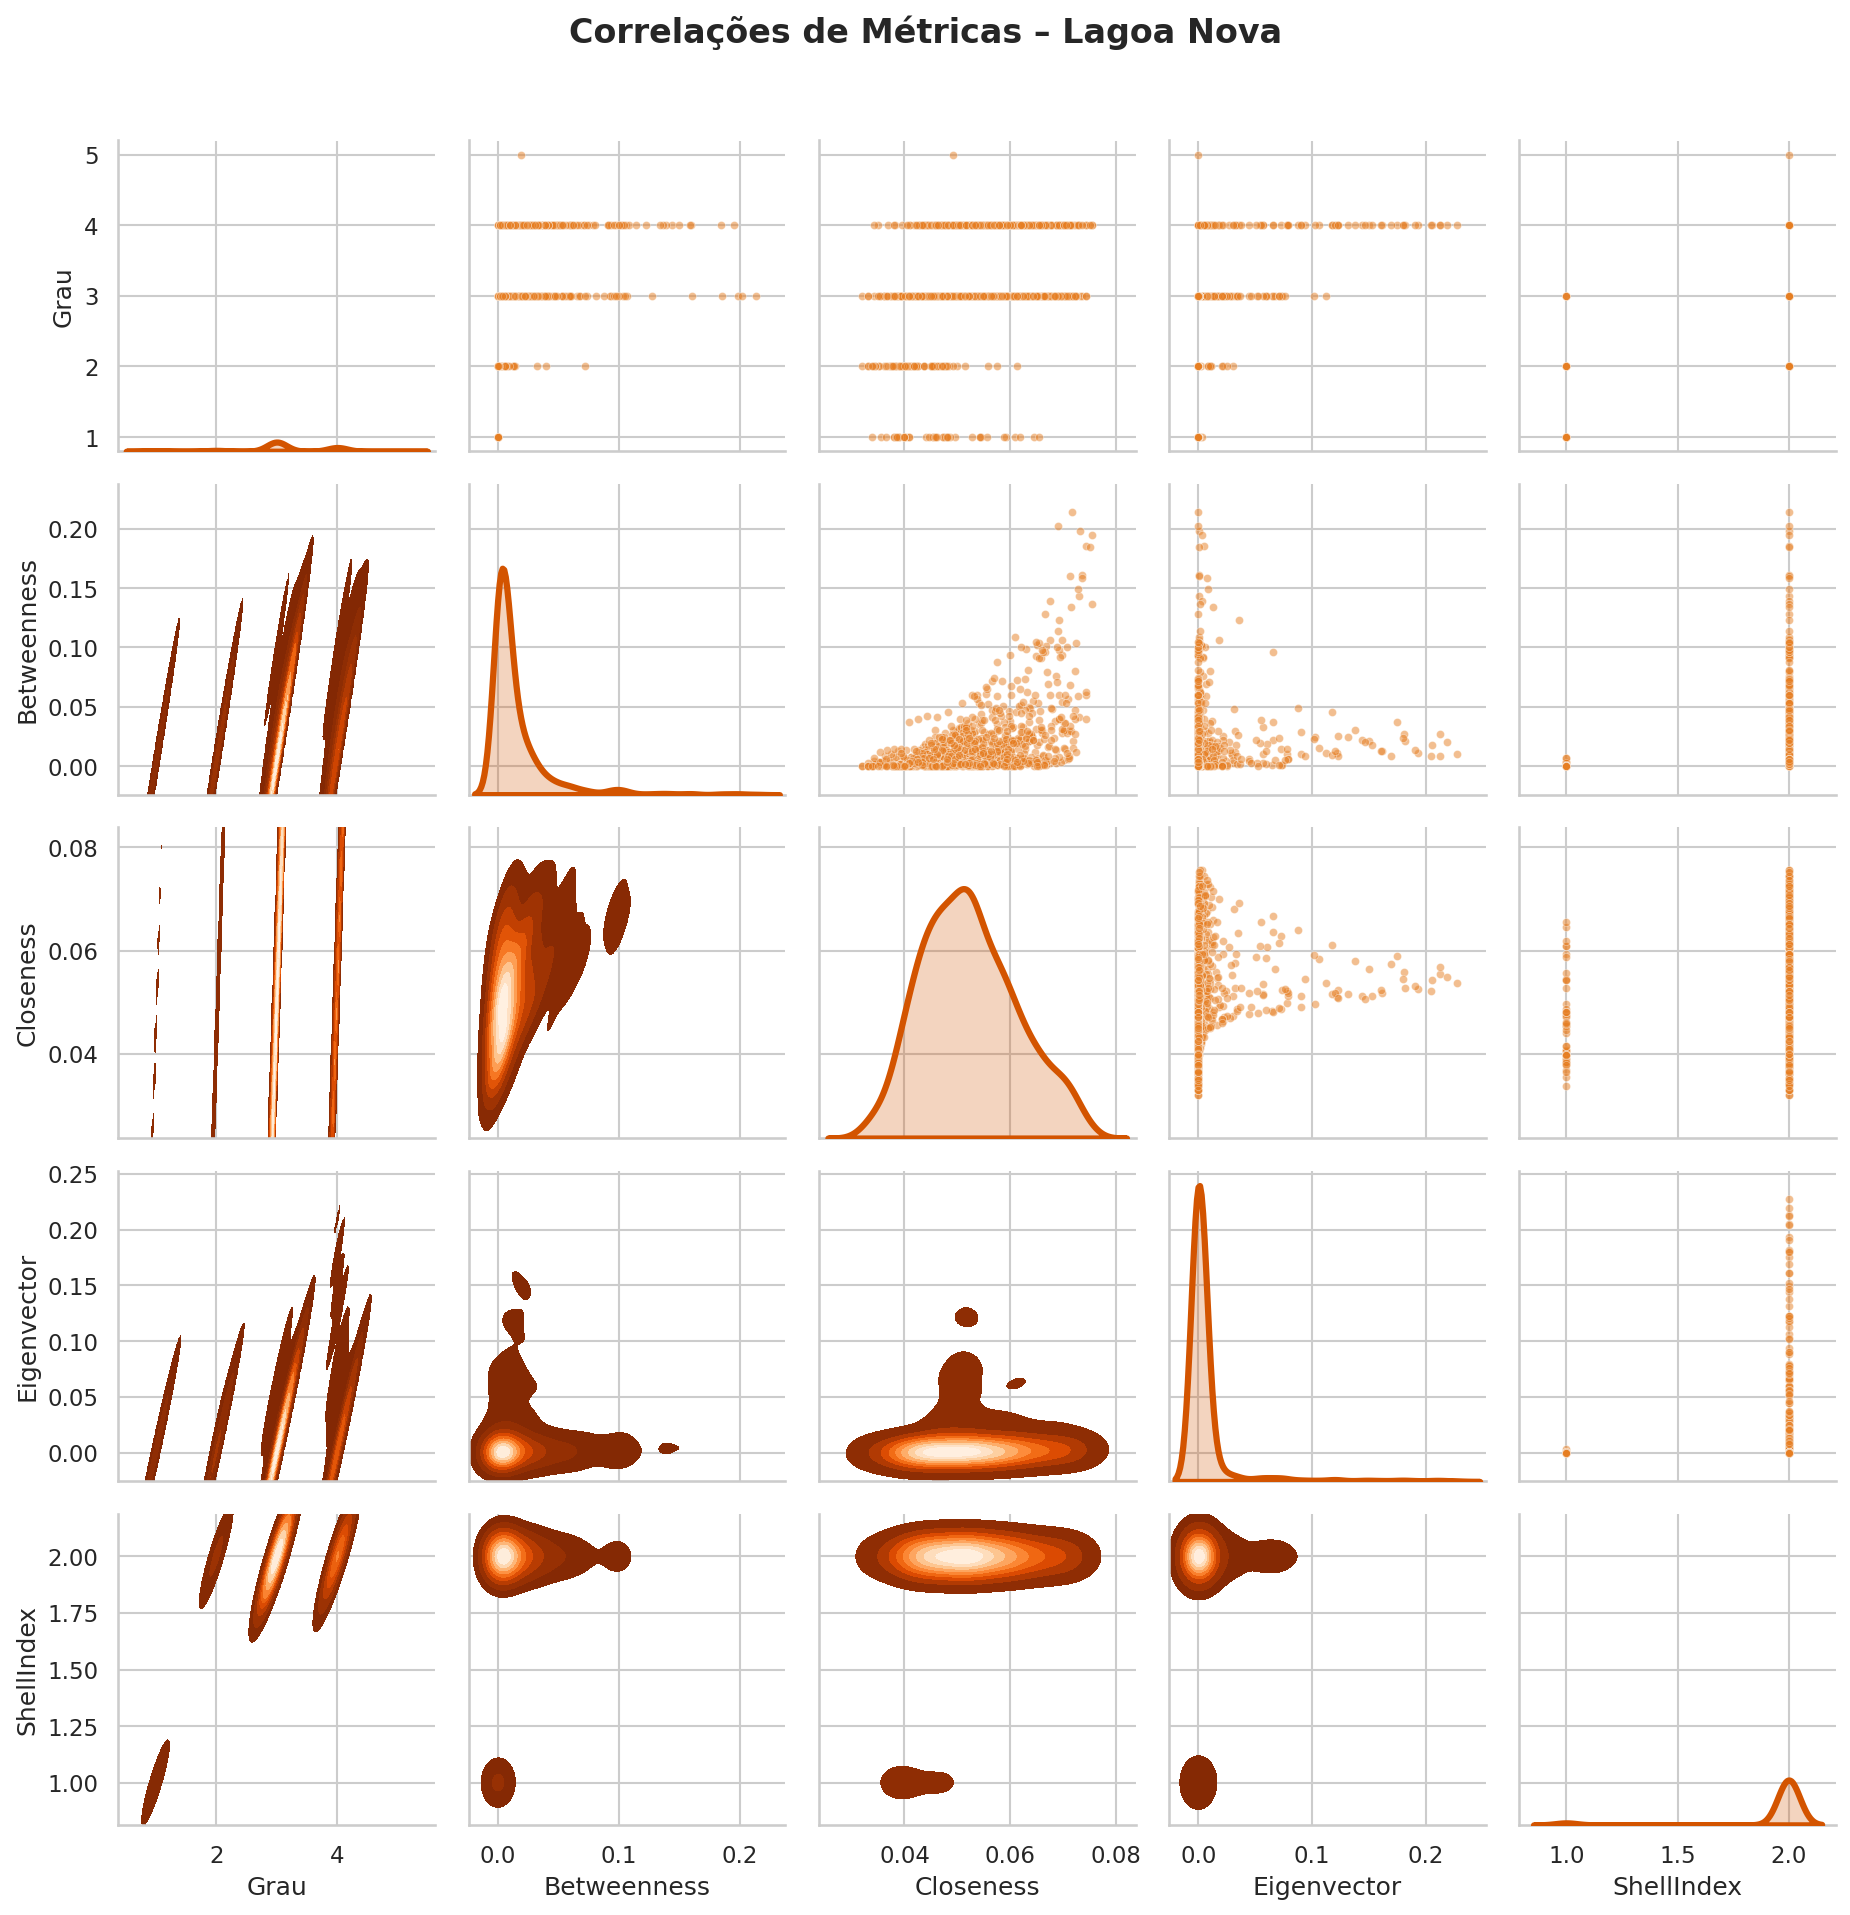

In [53]:
nodes_data = []
for node in G_simple.nodes():
    nodes_data.append({
        'Grau': degree_dict.get(node, 0),
        'Betweenness': betweenness.get(node, 0),
        'Closeness': closeness.get(node, 0),
        'Eigenvector': eigenvector.get(node, 0),
        'ShellIndex': core_number.get(node, 0)
    })

df = pd.DataFrame(nodes_data)
g = sns.PairGrid(df)
g.map_upper(sns.scatterplot, s=15, alpha=0.5, color='#E67E22')
g.map_lower(sns.kdeplot, cmap="Oranges_r", fill=True)
g.map_diag(sns.kdeplot, lw=3, color='#D35400', fill=True)
plt.suptitle('Correlações de Métricas – Lagoa Nova', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig08_pairgrid_metricas.png', bbox_inches='tight')
plt.show()

---
## Questões Analíticas Obrigatórias

1. **Os nós com maior grau coincidem com os nós de maior betweenness?**  
   Não necessariamente. Em Lagoa Nova, os nós de maior betweenness tendem a estar nas **avenidas de borda** (Hermes da Fonseca, Salgado Filho, Prudente de Morais), que funcionam como corredores de passagem entre bairros. Já os nós de maior grau estão nas interseções internas, onde mais ruas se encontram, mas cujo impacto no fluxo global é menor.

2. **O núcleo identificado pelo k-core coincide com os principais hubs?**  
   Parcialmente. O **Max K-Core** de Lagoa Nova deve residir na porção central do bairro, onde a malha em grade produz maior redundância de caminhos. Entretanto, os nós de maior betweenness ficam nos corredores de borda — topologicamente mais periféricos, mas funcionalmente mais críticos para o fluxo inter-bairros.

3. **O que a métrica de betweenness revela que o grau não revela?**  
   A betweenness revela a **importância global** de um nó para o fluxo de toda a rede. No contexto de Lagoa Nova, ela identifica as interseções com as avenidas estruturantes como os verdadeiros pontos de controle do tráfego. O grau, por ser uma métrica estritamente local, não captura essa posição estratégica — um nó com grau 3 numa avenida principal pode ter betweenness muito maior que um nó de grau 5 numa rua interna.

4. **O que muda entre a visualização geográfica e o layout estrutural?**  
   Na visualização geográfica, a forma do bairro é dominada pela presença do **Parque das Dunas** a leste, que impõe uma barreira física e limita a expansão da rede nessa direção. O layout estrutural (baseado em topologia) reorganiza os nós por conectividade, revelando que as ruas internas de baixo grau ficam na periferia do grafo independentemente de sua localização física no mapa.

5. **Existem regiões críticas para mobilidade urbana?**  
   Sim. As interseções das avenidas **Hermes da Fonseca**, **Salgado Filho** e **Prudente de Morais** concentram os maiores valores de betweenness e closeness. O entorno do **Shopping Midway Mall** também se destaca como polo de convergência, com alta densidade de ligações viárias.

6. **A rede parece homogênea ou apresenta concentração estrutural?**  
   A rede apresenta **concentração estrutural moderada**. A porção planejada em grade (região central) apresenta distribuição de grau mais homogênea e shells mais altos. As áreas de expansão residencial mais recente, com ruas curvilíneas e saídas únicas, formam shells externos com baixa resiliência estrutural.

7. **Os resultados obtidos fazem sentido considerando o conhecimento urbano da região?**  
   Sim. A alta betweenness nas avenidas de borda reflete a realidade cotidiana: Lagoa Nova é atravessada diariamente por tráfego de passagem entre o centro e a Zona Sul. A concentração do max k-core na área central, protegida da pressão viária das grandes avenidas, corresponde ao caráter residencial e relativamente tranquilo do interior do bairro.

---
## Etapa 4 – Exportação para o Gephi

Exportamos o grafo enriquecido (com todas as métricas como atributos de nó) nos formatos **GraphML** e **GEXF**, compatíveis com o Gephi. A conversão para grafo simples é necessária para evitar problemas de importação causados por arestas múltiplas do MultiGraph do OSMnx.

In [54]:
def export_to_gephi(G_input, city_name):
    """
    Exporta o grafo para o Gephi convertendo para Grafo SIMPLES.
    Isso evita problemas de importação de arestas múltiplas no Gephi.
    """
    # 1. Converter para Grafo Simples
    G_simple_export = nx.Graph(G_input)
    
    # Métricas numéricas
    numeric_metrics = ['grau', 'betweenness', 'closeness', 'shell_index', 'x', 'y']
    
    # 2. Limpeza Profunda
    for node, data in G_simple_export.nodes(data=True):
        keys_to_remove = [k for k, v in data.items() if k == 'geometry' or isinstance(v, (list, dict))]
        for k in keys_to_remove: del data[k]
        for k, v in data.items():
            if k not in numeric_metrics: data[k] = str(v)
                
    for u, v, data in G_simple_export.edges(data=True):
        keys_to_remove = [k for k, v in data.items() if k in ['geometry', 'osmid', 'nodes'] or isinstance(v, (list, dict))]
        for k in keys_to_remove: del data[k]
        for k, v in data.items():
            if k not in numeric_metrics: data[k] = str(v)
    
    nx.write_graphml(G_simple_export, f"rede_{city_name}.graphml")
    nx.write_gexf(G_simple_export, f"rede_{city_name}.gexf")
    
    print(f"Sucesso! Arquivos SIMPLES gerados: rede_{city_name}.graphml e .gexf")

export_to_gephi(G_und_multi, "lagoa_nova")

Sucesso! Arquivos SIMPLES gerados: rede_lagoa_nova.graphml e .gexf
